In [ ]:
# importing libraries that we'll use below
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

from scipy.stats import normaltest, spearmanr, kendalltau, mannwhitneyu, kruskal
import statsmodels.api as sm

from google.colab import auth, files, drive
import os
from google.cloud import bigquery

# Data Extraction from BigQuery and Standard Data Cleaning

In [ ]:
# Connecting and authentificating to BigQuery
auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")

In [ ]:
# Query to the BigQuery Database to extract data
query = """
WITH
  accounts_overview AS (
    SELECT *
    FROM `DA.account_session` AS acs
    LEFT JOIN `DA.account` AS acc
      ON acc.id = acs.account_id
  ),
  orders_overview AS (
    SELECT *
    FROM data-analytics-mate.DA.order
    LEFT JOIN data-analytics-mate.DA.product
      USING (item_id)
  ),
  session_overview AS (
    SELECT *
    FROM `DA.session`
    LEFT JOIN `DA.session_params`
      USING (ga_session_id)
  )
SELECT DISTINCT
  ses.date,
  ses.ga_session_id,
  ses.continent,
  ses.country,
  ses.device,
  ses.browser,
  ses.mobile_model_name,
  ses.operating_system,
  ses.language,
  ses.medium,
  ses.channel,
  acs.id,
  acs.is_verified,
  acs.is_unsubscribed,
  ord.category,
  ord.name,
  ord.price,
  ord.short_description
FROM session_overview AS ses
LEFT JOIN orders_overview AS ord
  USING (ga_session_id)
LEFT JOIN accounts_overview AS acs
  USING (ga_session_id)
"""

In [ ]:
# Running query
query_job = client.query(query)
results = query_job.result()

In [ ]:
# Transforming extracted data to the DataFrame
df = results.to_dataframe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   medium             349545 non-null  object 
 10  channel            349545 non-null  object 
 11  id                 27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  name               33538 non-null   object 
 16  pr

In [ ]:
# Columns quantity overview
columns_count = df.shape[1]
print(f"There are {columns_count} columns in the dataset")

There are 18 columns in the dataset


In [ ]:
# Datatypes quantity
df.dtypes.value_counts()

,count
object,12
Int64,4
dbdate,1
float64,1


In [ ]:
# Lists of each datatype columns
num_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"List of numeric columns:\n{num_columns}\n")

object_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"List of categorical columns:\n{object_columns}\n")

date_columns = df.select_dtypes(include=['dbdate']).columns.tolist()
print(f"List of datetime columns:\n{date_columns}")

List of numeric columns:
['ga_session_id', 'id', 'is_verified', 'is_unsubscribed', 'price']

List of categorical columns:
['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'medium', 'channel', 'category', 'name', 'short_description']

List of datetime columns:
['date']


In [ ]:
# General overview of quantity of unique values in the dataset
unique_sessions = df["ga_session_id"].nunique()
unique_accounts = df["id"].nunique()
orders_cnt = df["price"].count()
unique_countries = df["country"].nunique()
unique_continent = df["continent"].nunique()

print(f"Number of unique sessions: {unique_sessions}")
print(f"Number of unique accounts: {unique_accounts}")
print(f"Number of orders: {orders_cnt}")
print(f"Users are from {unique_countries} countries across {unique_continent} continents")

Number of unique sessions: 349545
Number of unique accounts: 27945
Number of orders: 33538
Users are from 108 countries across 6 continents


In [ ]:
# Analyzed Date range
date_range = df['date'].max() - df['date'].min()
print(f"Dataset contains orders within {date_range.days} days\nThe start date is {df['date'].min().strftime('%d-%b-%Y')} and the last date is {df['date'].max().strftime('%d-%b-%Y')}")

Dataset contains orders within 91 days
The start date is 01-Nov-2020 and the last date is 31-Jan-2021


In [ ]:
# Check for NULL (NA, missed) values
df.isna().sum()

,0
date,0
ga_session_id,0
continent,0
country,0
device,0
browser,0
mobile_model_name,0
operating_system,0
language,114266
medium,0


In [ ]:
# fill in language data to remove NULLs
df["language"] = df["language"].fillna("Unknown")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           349545 non-null  object 
 9   medium             349545 non-null  object 
 10  channel            349545 non-null  object 
 11  id                 27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  name               33538 non-null   object 
 16  pr

In [ ]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

The greatest number of missing data is in columns that were extracted from the table with the account overview. Also, there are many missing values in the product overview columns and the language.

Reasons:
- If the client didn't make any orders, the product overview columns would be empty. There is no need to drop these values.
- Also, there were clients who didn't register their accounts, but they used the website, so `id` and related data are missing for these people. There is no need to drop these values.
- Lastly, `language` was not tracked for everyone, so we have missing data there as well. It might be useful to check how the data is tracked and potentially improve the data collection process.

# Business Activity Overview

### TOP Overview by Continent, Country, Category

In [ ]:
# checking top-3 continents based on their revenue and orders count

top_3_continents_by_revenue_and_orders = df.groupby("continent")["price"].agg(total_revenue="sum", orders_count="count").nlargest(3, "total_revenue").reset_index()
top_3_continents_by_revenue_and_orders

,continent,total_revenue,orders_count
0,Americas,17665280.0,18553
1,Asia,7601298.3,7950
2,Europe,5934624.2,6261


In [ ]:
# checking top-5 countries based on their revenue and orders count
top_5_countries_by_revenue_and_orders = df.groupby("country")["price"].agg(total_revenue="sum", orders_count="count").nlargest(5, "total_revenue").reset_index()
top_5_countries_by_revenue_and_orders

,country,total_revenue,orders_count
0,United States,13943553.9,14673
1,India,2809762.0,3029
2,Canada,2437921.0,2560
3,United Kingdom,938317.9,1029
4,France,710692.8,678


In [ ]:
# checking top-10 product categories based on their revenue
top_10_categories_by_revenue = df.groupby("category")["price"].agg(total_revenue="sum").nlargest(10, "total_revenue").reset_index()
top_10_categories_by_revenue

,category,total_revenue
0,Sofas & armchairs,8388254.5
1,Chairs,6147748.8
2,Beds,4919725.0
3,Bookcases & shelving units,3640818.1
4,Cabinets & cupboards,2336499.5
5,Outdoor furniture,2142222.2
6,Tables & desks,1790307.5
7,Chests of drawers & drawer units,906562.5
8,Bar furniture,735503.0
9,Children's furniture,467697.0


In [ ]:
country_with_max_revenue = top_5_countries_by_revenue_and_orders.iloc[0]['country']
sales_in_country_with_max_revenue = df[df["country"] == country_with_max_revenue]

print(f"Country with the greatest revenue: {country_with_max_revenue}\n")

top_10_categories_in_country_with_max_revenue = sales_in_country_with_max_revenue.groupby("category")["price"].agg(total_revenue="sum").nlargest(10, "total_revenue").reset_index()
top_10_categories_in_country_with_max_revenue

Country with the greatest revenue: United States



,category,total_revenue
0,Sofas & armchairs,3707144.5
1,Chairs,2619773.8
2,Beds,2213058.0
3,Bookcases & shelving units,1567606.9
4,Cabinets & cupboards,994545.5
5,Outdoor furniture,929245.2
6,Tables & desks,777865.0
7,Chests of drawers & drawer units,382388.0
8,Bar furniture,330805.0
9,Children's furniture,207575.0


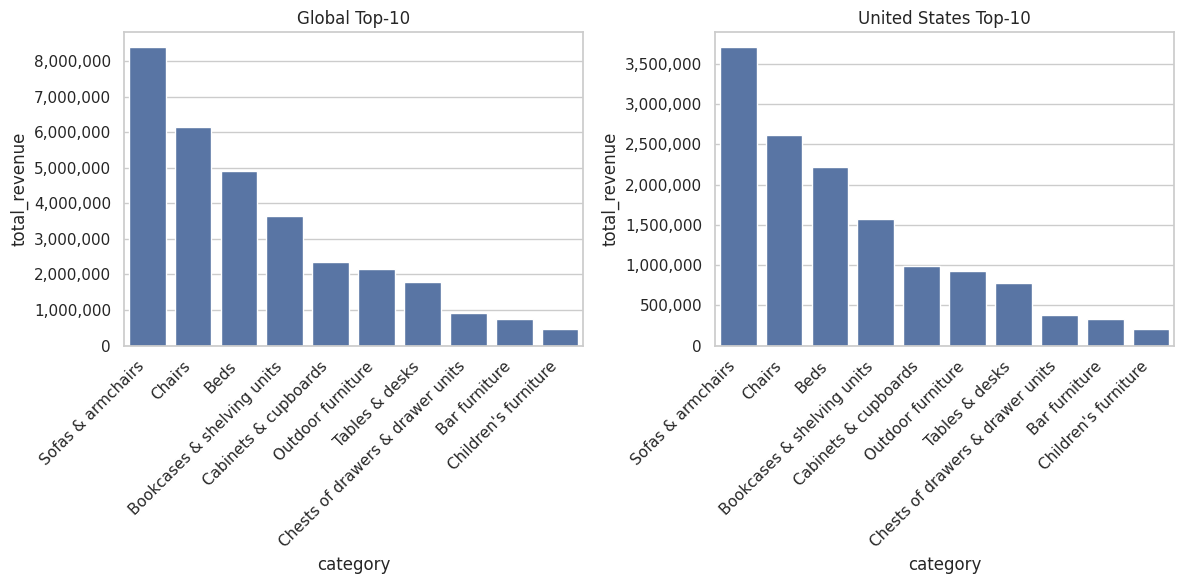

In [ ]:
# Adding subplot to highlight top-10 categories by revenue in general and compare them in a country with the greatest revenue
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.barplot(data=top_10_categories_by_revenue, x="category", y="total_revenue", ax=ax[0])
ax[0].set_title("Global Top-10")
ax[0].tick_params(axis='x', rotation=45)
plt.setp(ax[0].get_xticklabels(), rotation=45, ha='right')

sns.barplot(data=top_10_categories_in_country_with_max_revenue, x="category", y="total_revenue", ax=ax[1])
ax[1].set_title(f"{country_with_max_revenue} Top-10")
ax[1].tick_params(axis='x', rotation=45)
plt.setp(ax[1].get_xticklabels(), rotation=45, ha='right')

# Clean up scientific notation for both plots
for a in ax:
    a.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

plt.tight_layout()
plt.show()

As we can see, there are similar categories at the top, but the lists are not identical. This suggests that the United States (and likely other countries as well) has its own product preferences and demand patterns. Therefore, when entering new markets, we should take these differences into account and adapt our marketing strategies accordingly.

### Categories Distribution overview

In [ ]:
df.describe()

,ga_session_id,id,is_verified,is_unsubscribed,price
count,349545.0,27945.0,27945.0,27945.0,33538.000000
mean,4992250296.631739,659005.065557,0.71698,0.16944,953.298679
std,2887450949.537772,13216.529465,0.450474,0.375147,1317.001775
min,1205.0,636133.0,0.0,0.0,3.000000
25%,2493646855.0,647576.0,0.0,0.0,170.000000
50%,4988476074.0,658952.0,1.0,0.0,445.000000
75%,7491286508.0,670414.0,1.0,0.0,1195.000000
max,9999997129.0,681962.0,1.0,1.0,9585.000000


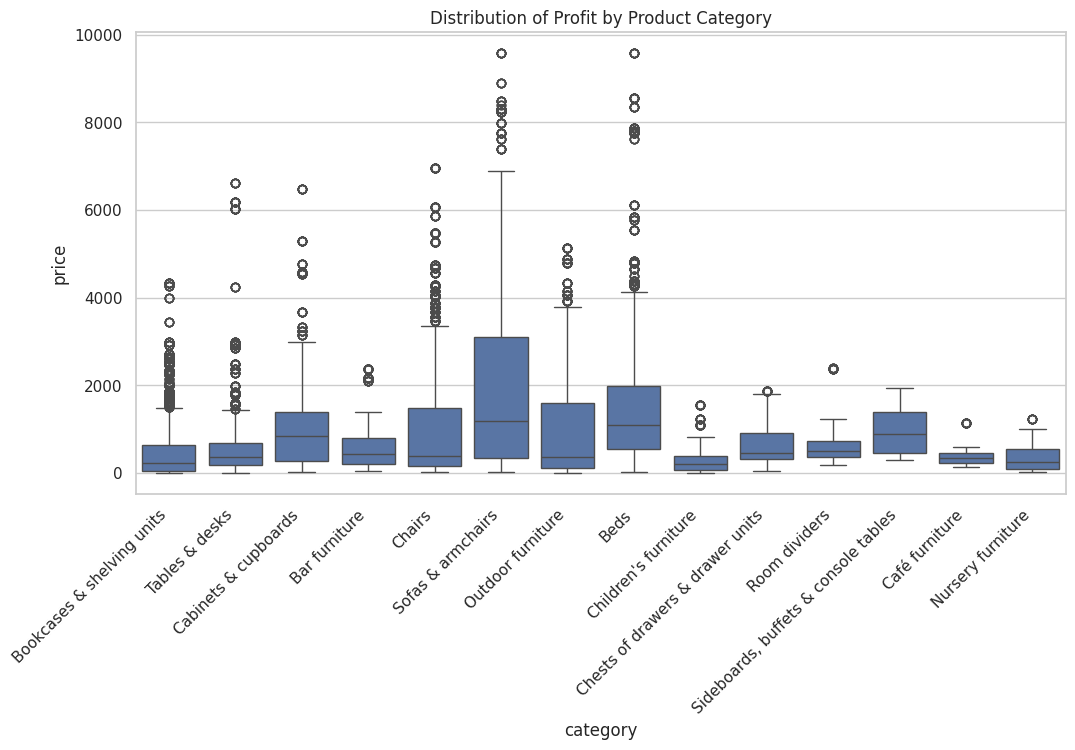

In [ ]:
plt.figure(figsize=(12, 6))

# Create the boxplot
sns.boxplot(data=df, x='category', y='price')

plt.xticks(rotation=45, ha='right')

plt.title('Distribution of Profit by Product Category')
plt.show()

The box plot shows how price/revenue is distributed within each category. We can see that almost every category contains outliers, represented by dots outside the whiskers. This means that most orders fall within the typical price range, while a small number of items are significantly more expensive than the rest.

These products may represent a separate “VIP” or premium segment, potentially targeting a different audience.

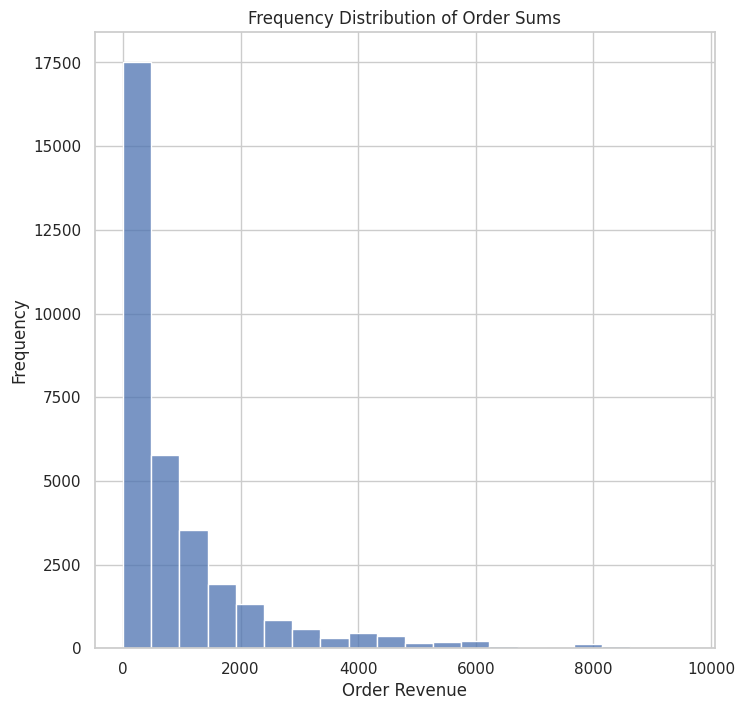

In [ ]:
plt.figure(figsize=(8, 8))

sns.histplot(data=df, x='price', bins=20)

plt.title('Frequency Distribution of Order Sums')
plt.xlabel('Order Revenue')
plt.ylabel('Frequency')

plt.show()

Since we found many outliers, it is important to check how frequently they appear in the orders.

As shown in the histogram, most orders are below USD 2,000, while only a very small (almost invisible) number of orders generate more than USD 6,000 in revenue.

This may indicate that these values are true outliers rather than a separate, well-developed customer segment within the company.

### Revenue Shares by Devices and Traffic Channels

In [ ]:
# Revenue overview generated by different devices
sales_by_device = df.groupby("device")["price"].agg(total_revenue="sum").reset_index()
sales_by_device

,device,total_revenue
0,desktop,18864039.0
1,mobile,12384225.8
2,tablet,723466.3


In [ ]:
fig_device = go.Figure(data=[go.Pie(
    labels=sales_by_device['device'],
    values=sales_by_device['total_revenue']
)])

fig_device.update_layout(
    title_text="Revenue by Device",
    height=400,
    width=600,
    template="plotly_white"
)

fig_device.show()

In [ ]:
# Revenue overview generated by different trafic channels
sales_by_channel = df.groupby("channel")["price"].agg(total_revenue="sum").reset_index()
sales_by_channel

,channel,total_revenue
0,Direct,7494923.4
1,Organic Search,11433151.6
2,Paid Search,8511049.4
3,Social Search,2532105.7
4,Undefined,2000501.0


In [ ]:
fig_device = go.Figure(data=[go.Pie(
    labels=sales_by_channel['channel'],
    values=sales_by_channel['total_revenue']
)])

fig_device.update_layout(
    title_text="Revenue by Channel",
    height=400,
    width=600,
    template="plotly_white"
)

fig_device.show()

**Note:** We did not remove the `Undefined` channel, as its meaning is similar to `Unknown`, so simply renaming it would not solve the issue. Additionally, as shown in the analysis, this channel still generates some revenue, meaning it cannot be excluded from the analysis.

Therefore, it should remain in the dataset while we also focus on improving the data collection process and reducing the amount of data assigned to the undefined channel.

### Users status overviews

In [ ]:
# Registered users check and share
registered_users = df[~df["id"].isna()]
total_registered_users = registered_users["id"].count()

verified_users = registered_users[registered_users["is_verified"] == 1]
total_verified_users = verified_users["is_verified"].shape[0]

perc_verified_users = (total_verified_users / total_registered_users) * 100

print(f"Number of registered users: {total_registered_users}\nNumber of verified users: {total_verified_users}\n")
print(f"Percent of verified users out of all registered ones: {perc_verified_users: .2f}%")

Number of registered users: 27945
Number of verified users: 20036

Percent of verified users out of all registered ones:  71.70%


In [ ]:
# Unsubscribed from newsletter users check and share
unsubscribed_users = verified_users[verified_users["is_unsubscribed"] == 1]
total_is_unsubscribed = unsubscribed_users["is_unsubscribed"].shape[0]

perc_unsubscribed_users = (total_is_unsubscribed / total_verified_users) * 100

print(f"Number of unsubscribed users: {total_is_unsubscribed}\n")
print(f"Percent of unsubscribed users out of all verified ones: {perc_unsubscribed_users: .2f}%")

Number of unsubscribed users: 4304

Percent of unsubscribed users out of all verified ones:  21.48%


As we can see, more than **70% of users** have verified their emails, and almost **80%** are still subscribed to the company's newsletter. These levels are pretty good ones but we still can think how to increase them.

It is worth mentioning that the dataset contains around **349k records**, while only **27,945 users** are registered. This may indicate that only a small share of users are interested enough in the products to create an account, suggesting a significant gap between sessions and registrations.

However, we cannot directly compare the number of sessions with the number of accounts, since one user may generate multiple sessions. Therefore, we cannot accurately calculate the percentage of users who did not register or build a fully transparent marketing funnel based on this data.

In [ ]:
# Countries with the greatest number of registered users
top_10_countries_by_registered_users = registered_users.groupby("country")["id"].agg(registered_users="count").nlargest(10, "registered_users").reset_index()
top_10_countries_by_registered_users

,country,registered_users
0,United States,12384
1,India,2687
2,Canada,2067
3,United Kingdom,859
4,France,553
5,Spain,536
6,Taiwan,500
7,China,490
8,Germany,490
9,Italy,386


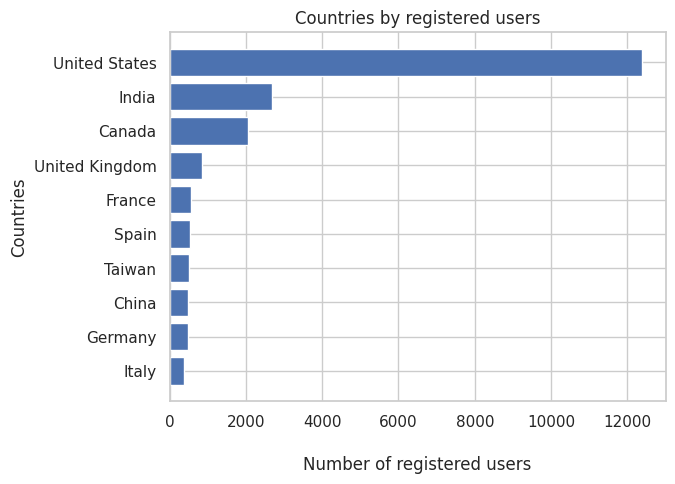

In [ ]:
# Visual overview of TOP-10 countries with the most users registered
plt.barh(top_10_countries_by_registered_users["country"], top_10_countries_by_registered_users["registered_users"])
plt.title("Countries by registered users")
plt.ylabel("Countries")
plt.xlabel("\nNumber of registered users")
plt.gca().invert_yaxis()
plt.show()

We see a huge gap between the United States and all the other countries. It indicates that the USA is one of our key markets.

# Sales Dynamics Overview

### Revenue dynamics (general overview)

In [ ]:
# Revenue by date overview
sales_by_date = df.groupby("date")["price"].agg(total_revenue="sum").reset_index()
sales_by_date.head()

,date,total_revenue
0,2020-11-01,244292.5
1,2020-11-02,355506.8
2,2020-11-03,498979.6
3,2020-11-04,339187.1
4,2020-11-05,391276.6


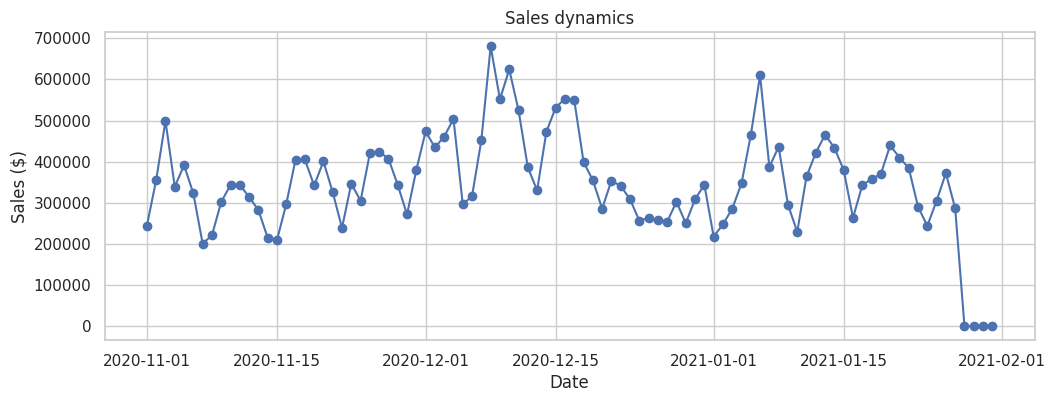

In [ ]:
# Daily Revenue overview
plt.figure(figsize=(12, 4))

plt.plot(sales_by_date["date"], sales_by_date["total_revenue"], marker="o")
plt.title("Sales dynamics")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.show()

We did not have any sales at the end of January, while some sessions were still recorded. As a result, we see values close to 0 at the end of the graph.

Also, checking our daily revenue is not fully convenient, so for the following analysis we'll group our dates based on higher levels of details (weeks, months, etc.)

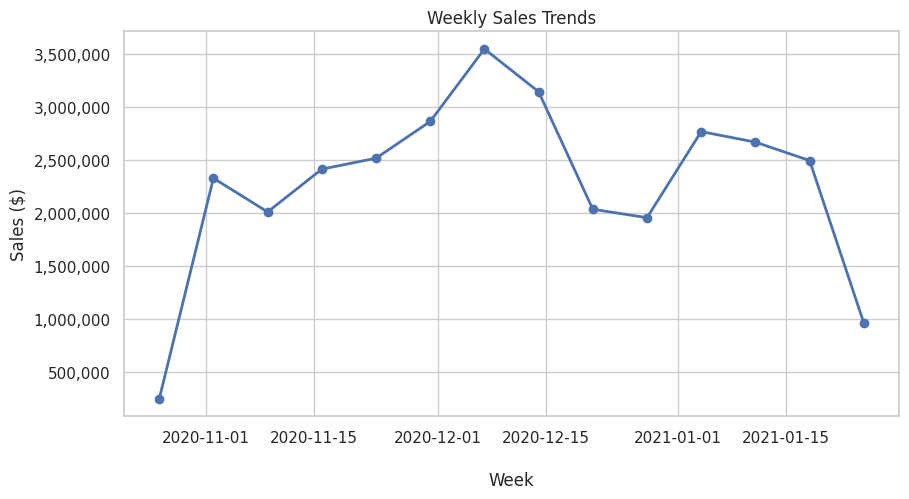

In [ ]:
# Weekly revenue
df['date'] = pd.to_datetime(df['date'])

weekly_sales = df.groupby(df['date'].dt.to_period('W'))['price'].sum().reset_index()
weekly_sales['date'] = weekly_sales['date'].dt.to_timestamp()

plt.figure(figsize=(10, 5))
plt.plot(weekly_sales['date'], weekly_sales['price'], marker='o', linewidth=2)
plt.title("Weekly Sales Trends")
plt.ylabel("Sales ($)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xlabel("\nWeek")
plt.show()

It is quite difficult to identify a clear trend in the graph above due to the high volatility during these weeks.

One interesting observation is that sales decrease before Christmas, which may indicate that our products are not typically considered as gifts.

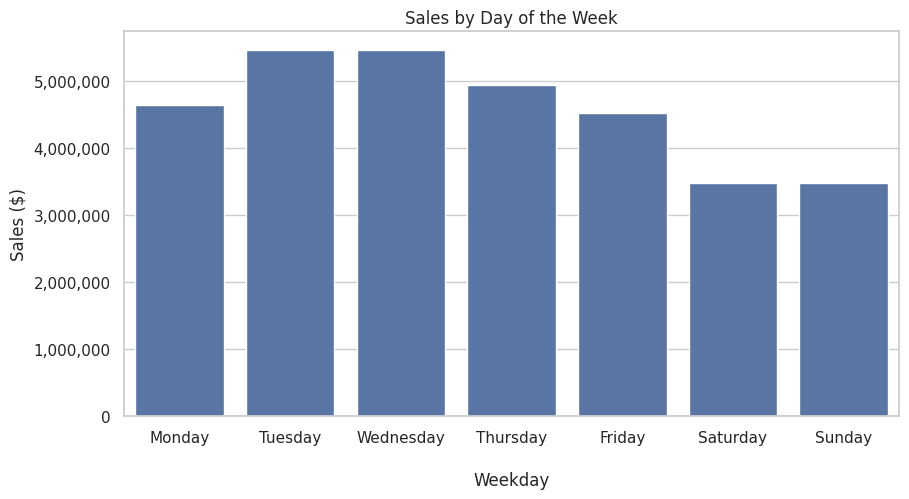

In [ ]:
# Weekly seasonal check
df['day_of_week'] = df['date'].dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='day_of_week', y='price', order=days_order, estimator=sum, errorbar=None)
plt.title("Sales by Day of the Week")
plt.ylabel("Sales ($)")
plt.xlabel("\nWeekday")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

There is a trend showing that the company’s products sell better on weekdays, while demand decreases during weekends. We should keep this in mind when designing marketing campaigns, as aligning them with these daily trends could improve campaign performance.

### Revenue dynamics by continents

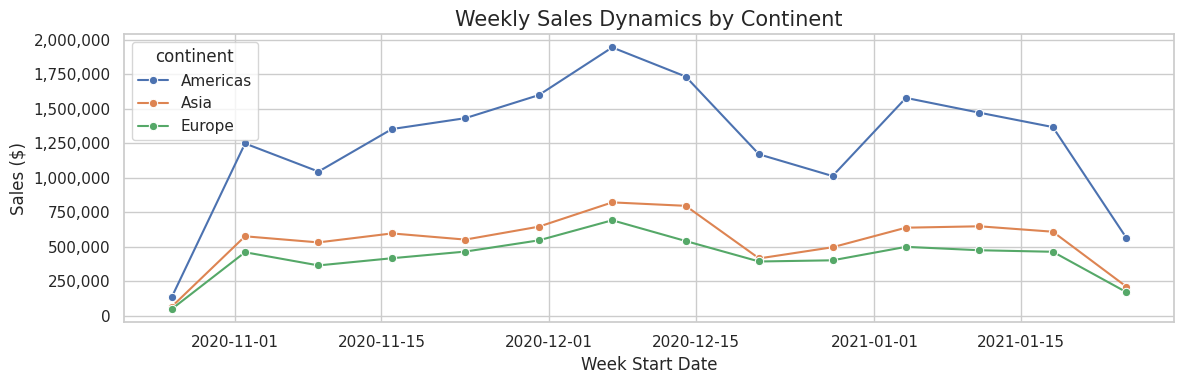

In [ ]:
filtered_continents = df[df["continent"].isin(["Americas", "Asia", "Europe"])].copy()

weekly_sales_by_continent = filtered_continents.groupby([filtered_continents['date'].dt.to_period('W'), "continent"])["price"].sum().reset_index()
weekly_sales_by_continent['date'] = weekly_sales_by_continent['date'].dt.to_timestamp()

plt.figure(figsize=(12, 4))
sns.lineplot(data=weekly_sales_by_continent, x='date', y='price', hue='continent', marker='o')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.title("Weekly Sales Dynamics by Continent", fontsize=15)
plt.ylabel("Sales ($)")
plt.xlabel("Week Start Date")

plt.tight_layout()
plt.show()

As we can see, there are similar trends on different continents, which means if we make the prediction for one continent, there is a higher chance that it'll work for another continent as well.

### Revenue dynamics by Traffic channels

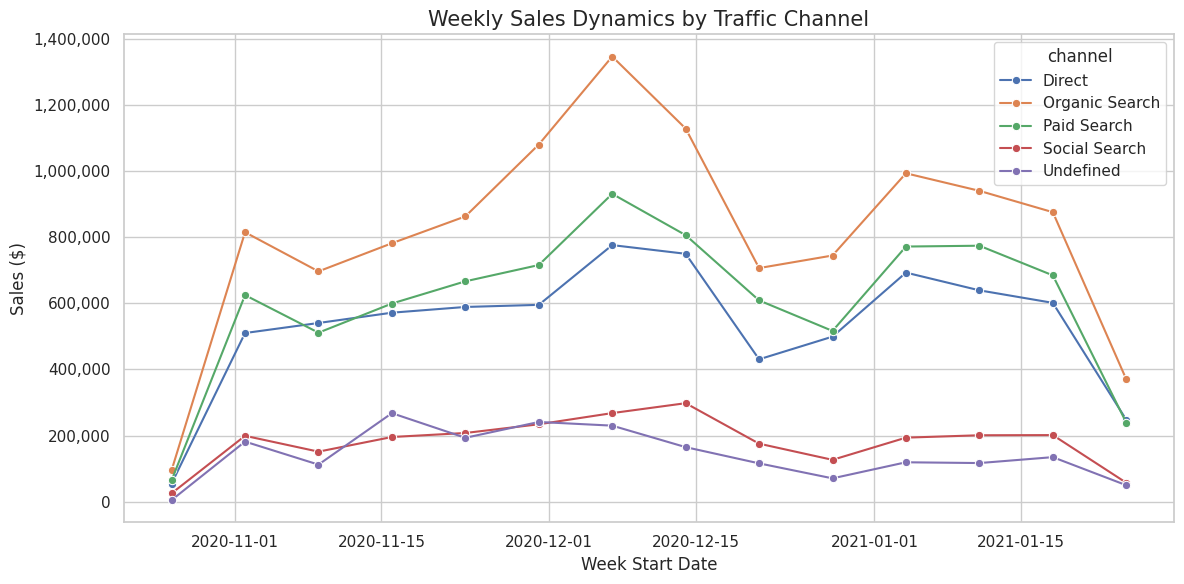

In [ ]:
weekly_sales_by_channel = df.groupby([df['date'].dt.to_period('W'), "channel"])["price"].sum().reset_index()
weekly_sales_by_channel['date'] = weekly_sales_by_channel['date'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(data=weekly_sales_by_channel, x='date', y='price', hue='channel', marker='o')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.title("Weekly Sales Dynamics by Traffic Channel", fontsize=15)
plt.ylabel("Sales ($)")
plt.xlabel("Week Start Date")

plt.tight_layout()
plt.show()

As shown in the graph, the highest revenue is generated by **Organic Search**. This is a very positive result for the company, as it is a free channel and does not require direct investment.

Additionally, revenue from the **Undefined** traffic channel is at the lowest level, meaning that for most of the revenue, we know the traffic source and can evaluate channel performance quite accurately.

### Revenue dynamics by devices

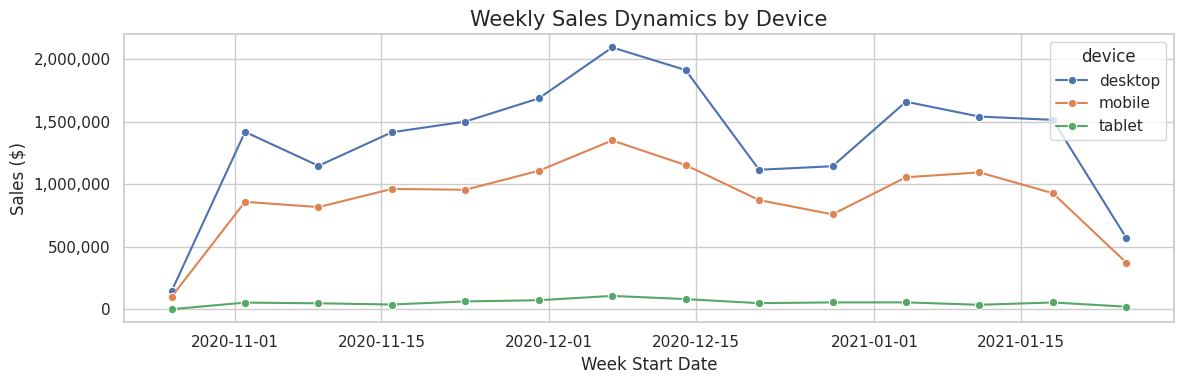

In [ ]:
weekly_sales_by_device = df.groupby([df['date'].dt.to_period('W'), "device"])["price"].sum().reset_index()
weekly_sales_by_device['date'] = weekly_sales_by_device['date'].dt.to_timestamp()

plt.figure(figsize=(12, 4))
sns.lineplot(data=weekly_sales_by_device, x='date', y='price', hue='device', marker='o')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.title("Weekly Sales Dynamics by Device", fontsize=15)
plt.ylabel("Sales ($)")
plt.xlabel("Week Start Date")

plt.tight_layout()
plt.show()

Tablets generate the lowest revenue, so if the company needs to discontinue support for certain device types to optimize operational costs, we recommend starting with tablets.

# Pivot tables

In [ ]:
# Overview how traffic channels were distributed among device types
pivot_session_cnt_by_channel_device = pd.pivot_table(
    df, values="ga_session_id", index="channel", columns="device", aggfunc="count"
).reset_index()
pivot_session_cnt_by_channel_device

device,channel,desktop,mobile,tablet
0,Direct,47825,31745,1812
1,Organic Search,72622,49014,2789
2,Paid Search,55167,37034,2140
3,Social Search,16288,10988,638
4,Undefined,12527,8486,470


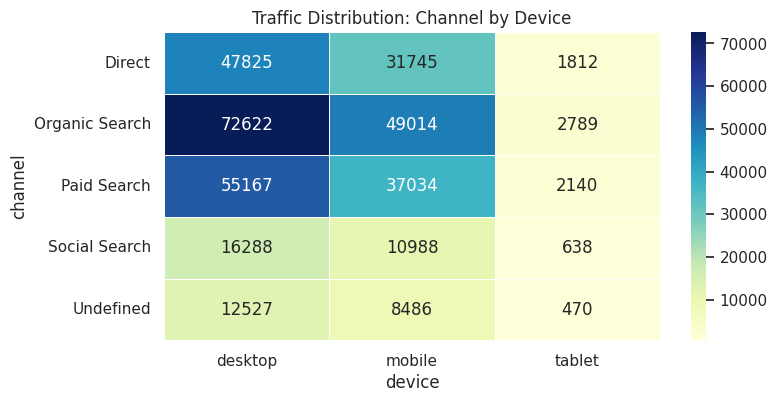

In [ ]:
# Data preparation
plot_data = pivot_session_cnt_by_channel_device.set_index('channel')
plot_data = plot_data.fillna(0).astype(float)

plt.figure(figsize=(8, 4))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title('Traffic Distribution: Channel by Device')
plt.show()

The graph shows that most of the company's sessions are generated through Organic Search and desktop devices. Based on these results, the company can adjust its marketing investments to further strengthen these channels by focusing on SEO, website improvements, and other initiatives that enhance organic visibility and desktop user experience.

### TOP-Countries and their TOP-Categories overview

In [ ]:
# Lists of top-countries and top-categories
top_countries = df.groupby('country')['price'].sum().nlargest(5).index
top_categories = df.groupby('category')['price'].sum().nlargest(10).index

df_filtered_for_pivot = df[(df["country"].isin(top_countries)) & (df["category"].isin(top_categories))]

pivot_sales_by_top_cat_prod = pd.pivot_table(df_filtered_for_pivot, values="price", index="category", columns="country", aggfunc="sum").reset_index()
pivot_sales_by_top_cat_prod = pivot_sales_by_top_cat_prod.sort_values(by="category")
pivot_sales_by_top_cat_prod

country,category,Canada,France,India,United Kingdom,United States
0,Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
1,Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
2,Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
3,Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
4,Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
5,Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
6,Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
7,Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
8,Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5
9,Tables & desks,132678.0,42299.0,186157.5,49374.0,777865.0


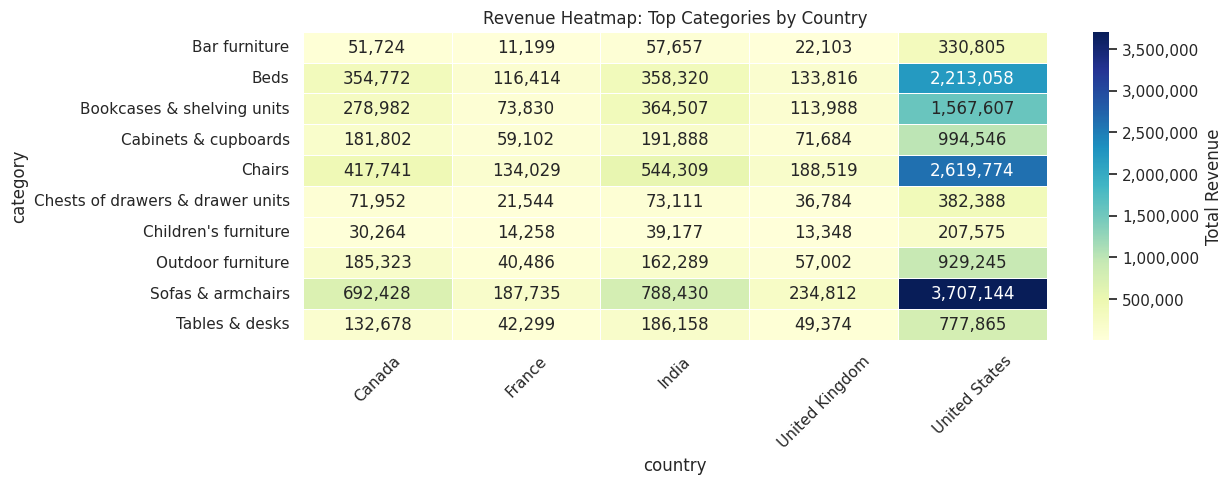

In [ ]:
# Data preparation
pivot_data = pivot_sales_by_top_cat_prod.set_index('category')
plot_data = plot_data.fillna(0).astype(float)

plt.figure(figsize=(12, 4))

sns.heatmap(
    pivot_data,
    annot=True,
    fmt=",.0f",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={
        'label': 'Total Revenue',
        'format': ticker.StrMethodFormatter('{x:,.0f}')
    }
)

plt.title('Revenue Heatmap: Top Categories by Country')
plt.xticks(rotation=45)
plt.show()

As we can see from the heat map, the **United States** generates the highest revenue across almost all categories. Additionally, **Sofas & Armchairs** appears to generate the highest revenue overall, as its values show the strongest color intensity across different countries.

# Statistical Analysis of Correlation

### Correlation check: Sessions and Sales by dates

In [ ]:
daily_sessions_sales = df.groupby(df['date']).agg(
    total_sessions=('ga_session_id', 'count'),
    total_revenue=('price', 'sum')
).reset_index()

daily_sessions_sales.head()

,date,total_sessions,total_revenue
0,2020-11-01,2576,244292.5
1,2020-11-02,3599,355506.8
2,2020-11-03,5173,498979.6
3,2020-11-04,4184,339187.1
4,2020-11-05,3743,391276.6


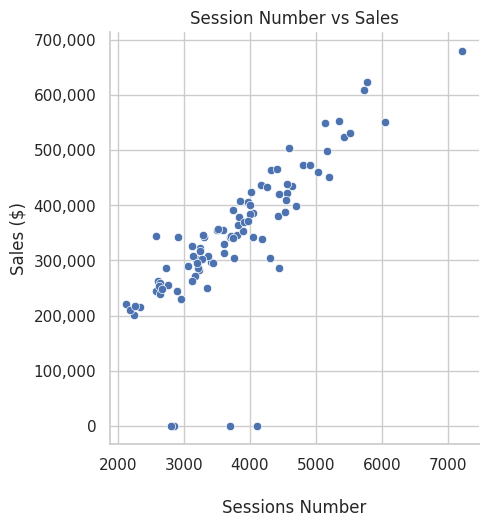

In [ ]:
# Visual check for the correlation
sns.relplot(x='total_sessions',y='total_revenue', data=daily_sessions_sales)
plt.title("Session Number vs Sales")
plt.xlabel("\nSessions Number")
plt.ylabel("Sales ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.show()

In [ ]:
# Performing Normality check
daily_sessions_sales_for_test = daily_sessions_sales[["total_sessions", "total_revenue"]].astype(float)
stat, p_value = normaltest(daily_sessions_sales_for_test)

print(f"D'Agostino-Pearson statistics: {stat}\np-value: {p_value}")

D'Agostino-Pearson statistics: [9.49913709 7.71831543]
p-value: [0.00865543 0.02108575]


In both cases, the p-values are smaller than 0.05 (the typical alpha level), so we cannot confirm the normality hypothesis. Based on this, we can conclude that the data is not normally distributed, and we need to use statistical tests designed for non-normally distributed data.

In [ ]:
spearman_corr = daily_sessions_sales_for_test["total_sessions"].corr(daily_sessions_sales_for_test["total_revenue"], method="spearman")
print(f"Spearman Correlation: {spearman_corr}\n")

kendall_corr = daily_sessions_sales_for_test["total_sessions"].corr(daily_sessions_sales_for_test["total_revenue"], method="kendall")
print(f"Kendall Correlation: {kendall_corr}")

Spearman Correlation: 0.8653062174563682

Kendall Correlation: 0.717666930923723


We used both correlation methods to additionally check whether outliers affect the results.

As we can see, in both cases the correlation is greater than **0.7**, which indicates a strong positive correlation between the number of sessions and sales levels.

## Sales Correlation between Continents

In [ ]:
top_3_continent_names = top_3_continents_by_revenue_and_orders["continent"].tolist()

pivot_top_continents_sales_dynamics = df[df["continent"].isin(top_3_continent_names)].pivot_table(
    index='date',
    columns='continent',
    values='price',
    aggfunc='sum'
).reset_index()

pivot_top_continents_sales_dynamics.head()

continent,date,Americas,Asia,Europe
0,2020-11-01,132002.5,63823.0,46908.0
1,2020-11-02,193861.0,79370.0,75710.8
2,2020-11-03,294529.8,126737.8,67692.0
3,2020-11-04,200009.5,66602.0,65915.0
4,2020-11-05,182988.2,117608.4,86540.0


We will skip further normality tests. Since our dataset is relatively small (n = 91 days), we will use Kendall's Tau correlation, as it is more robust for smaller samples and non-normal distributions.

In [ ]:
#Statistical Significance of Correlations (Kendall's Tau):

for i in range(len(top_3_continent_names)):
    for j in range(i + 1, len(top_3_continent_names)):
        c1, c2 = top_3_continent_names[i], top_3_continent_names[j]

        # Calculate tau and p-value
        tau, p_value = kendalltau(pivot_top_continents_sales_dynamics[c1],
                                  pivot_top_continents_sales_dynamics[c2])

        print(f"{c1} vs {c2}:")
        print(f"Kendall Tau: {tau:.4f}, p-value: {p_value:.4e}")

        if p_value < 0.05:
            print("Result: Statistically Significant (p < 0.05)\n")
        else:
            print("Result: Not Statistically Significant (p >= 0.05)\n")

Americas vs Asia:
Kendall Tau: 0.5172, p-value: 3.0377e-13
Result: Statistically Significant (p < 0.05)

Americas vs Europe:
Kendall Tau: 0.4986, p-value: 2.0711e-12
Result: Statistically Significant (p < 0.05)

Asia vs Europe:
Kendall Tau: 0.4809, p-value: 1.2018e-11
Result: Statistically Significant (p < 0.05)



In all cases we got statistically significant results. It means there is a statistically significant monotonic correlation between your two variables.

Additionally, our Kendall’s Tau values are around 0.5, which shows a moderate positive correlation between the variables.

In [ ]:
# Kendall's Tau Correlation Statistics overview as matrics
kendall_matrix_continent = pivot_top_continents_sales_dynamics[top_3_continent_names].corr(method='kendall')
print("Kendall Correlation Matrix for Top-3 Continents:")
print(kendall_matrix_continent)

Kendall Correlation Matrix for Top-3 Continents:
continent  Americas      Asia    Europe
continent                              
Americas   1.000000  0.517225  0.498565
Asia       0.517225  1.000000  0.480861
Europe     0.498565  0.480861  1.000000


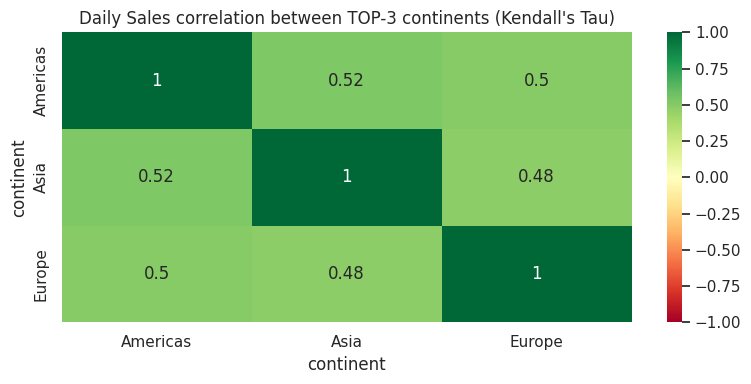

In [ ]:
plt.figure(figsize=(8, 4))
sns.heatmap(
    kendall_matrix_continent,
    annot=True,
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
)

plt.title("Daily Sales correlation between TOP-3 continents (Kendall's Tau)")
plt.tight_layout()
plt.show()

## Sales correlation between Traffic Channels

In [ ]:
daily_channels = df.pivot_table(
    index='date',
    columns='channel',
    values='price',
    aggfunc='sum'
)

daily_channels.head()

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
date,,,,,
2020-11-01,54669.5,95112.0,64688.0,25078.0,4745.0
2020-11-02,81561.5,127746.5,104780.8,16843.0,24575.0
2020-11-03,102909.5,182521.9,152641.3,27652.5,33254.4
2020-11-04,79683.6,117067.1,100332.0,24257.4,17847.0
2020-11-05,83367.6,122938.4,107648.0,41693.2,35629.4


In [ ]:
channel_names = daily_channels.columns.tolist()

for channel in channel_names:
    stat, p_value = normaltest(daily_channels[channel])

    print(f"Normality Test for {channel}:")
    print(f"p-value: {p_value}")

    if p_value > 0.05:
      print(f"Normally Distributed\n")
    else:
      print(f"Not Normally Distributed\n")

Normality Test for Direct:
p-value: 0.1278340958658422
Normally Distributed

Normality Test for Organic Search:
p-value: 0.048556169543642155
Not Normally Distributed

Normality Test for Paid Search:
p-value: 0.05912646179612032
Normally Distributed

Normality Test for Social Search:
p-value: 0.658907510677385
Normally Distributed

Normality Test for Undefined:
p-value: 0.06163185557875798
Normally Distributed



As we can see, Organic Search is not normally distributed, so we cannot apply tests that assume normality to other pairs of variables. Based on this, and given the relatively small dataset, we should use Kendall's Tau to calculate the correlation.

In [ ]:
for i in range(len(channel_names)):
    for j in range(i + 1, len(channel_names)):
        channel_1, channel_2 = channel_names[i], channel_names[j]

        # Calculate tau and p-value
        tau, p_value = kendalltau(daily_channels[channel_1],
                                  daily_channels[channel_2])

        print(f"{channel_1} vs {channel_2}:")
        print(f"Kendall Tau: {tau}, p-value: {p_value}")

        if p_value < 0.05:
            print("Result: Statistically Significant (p < 0.05)\n")
        else:
            print("Result: Not Statistically Significant (p >= 0.05)\n")

Direct vs Organic Search:
Kendall Tau: 0.5966507177033492, p-value: 4.01037243362041e-17
Result: Statistically Significant (p < 0.05)

Direct vs Paid Search:
Kendall Tau: 0.5531100478468899, p-value: 6.255567261464013e-15
Result: Statistically Significant (p < 0.05)

Direct vs Social Search:
Kendall Tau: 0.33636363636363636, p-value: 2.109657207955024e-06
Result: Statistically Significant (p < 0.05)

Direct vs Undefined:
Kendall Tau: 0.38851674641148326, p-value: 4.30235629120307e-08
Result: Statistically Significant (p < 0.05)

Organic Search vs Paid Search:
Kendall Tau: 0.609090909090909, p-value: 8.849773040955019e-18
Result: Statistically Significant (p < 0.05)

Organic Search vs Social Search:
Kendall Tau: 0.3282296650717703, p-value: 3.693222634293919e-06
Result: Statistically Significant (p < 0.05)

Organic Search vs Undefined:
Kendall Tau: 0.3698564593301435, p-value: 1.8395163003929308e-07
Result: Statistically Significant (p < 0.05)

Paid Search vs Social Search:
Kendall Tau:

In [ ]:
kendall_matrix_channel = daily_channels.corr(method='kendall')
print("Kendall Correlation Matrix for Traffic Channels:")
print(kendall_matrix_channel)

Kendall Correlation Matrix for Traffic Channels:
channel           Direct  Organic Search  Paid Search  Social Search  \
channel                                                                
Direct          1.000000        0.596651     0.553110       0.336364   
Organic Search  0.596651        1.000000     0.609091       0.328230   
Paid Search     0.553110        0.609091     1.000000       0.349761   
Social Search   0.336364        0.328230     0.349761       1.000000   
Undefined       0.388517        0.369856     0.396172       0.324880   

channel         Undefined  
channel                    
Direct           0.388517  
Organic Search   0.369856  
Paid Search      0.396172  
Social Search    0.324880  
Undefined        1.000000  


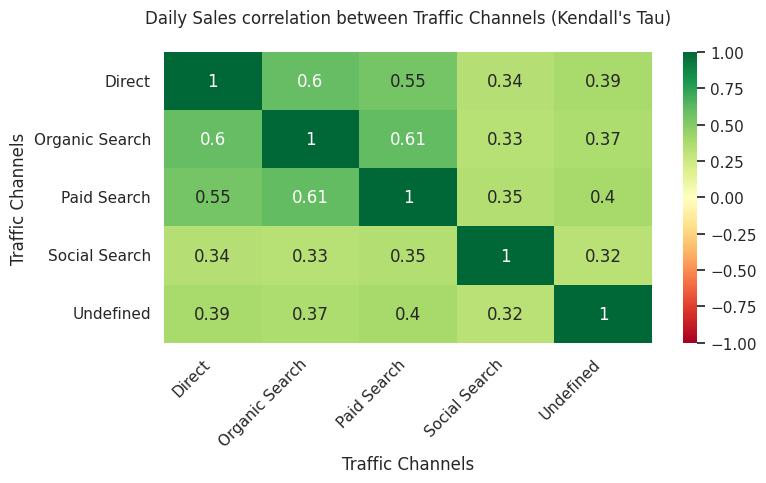

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    kendall_matrix_channel,
    annot=True,
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
)

plt.title("Daily Sales correlation between Traffic Channels (Kendall's Tau)\n")
plt.xlabel("Traffic Channels")
plt.ylabel("Traffic Channels")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

As we can see from the graph, there are low to moderate correlations between most traffic channels and sales.

However, Organic Search shows an almost strong positive correlation. This is a positive result, as it is a free channel and suggests that when the website reaches its target audience organically, there is a higher likelihood of users making a purchase.

Additionally, we checked that our results are statistically significant and not random as p-value < 0.05

### Sales Correlation between TOP-5 product categories by generated revenue

In [ ]:
top_5_categories_by_revenue_list = df.groupby("category")["price"].sum().nlargest(5).index.tolist()

daily_top_5_categories = df[df['category'].isin(top_5_categories_by_revenue_list)].pivot_table(
    index='date',
    columns='category',
    values='price',
    aggfunc='sum'
)

daily_top_5_categories.head()

category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
date,,,,,
2020-11-01,14041.0,36701.0,13591.5,46006.0,75216.0
2020-11-02,79683.5,40979.0,21623.0,58834.0,79977.5
2020-11-03,66219.5,64360.1,33555.5,61204.0,175594.0
2020-11-04,48939.0,35719.8,19266.0,44113.0,86861.5
2020-11-05,23449.0,40998.8,29235.0,90388.4,137288.0


In [ ]:
category_names = daily_top_5_categories.columns.tolist()

for category in category_names:
    stat, p_value = normaltest(daily_top_5_categories[category])

    print(f"Normality Test for {category}:")
    print(f"p-value: {p_value}")

    if p_value > 0.05:
      print(f"Normally Distributed\n")
    else:
      print(f"Not Normally Distributed\n")

Normality Test for Beds:
p-value: 2.1452760355452934e-05
Not Normally Distributed

Normality Test for Bookcases & shelving units:
p-value: 0.015258119024676019
Not Normally Distributed

Normality Test for Cabinets & cupboards:
p-value: 0.0006516690890353964
Not Normally Distributed

Normality Test for Chairs:
p-value: 0.001152458339643346
Not Normally Distributed

Normality Test for Sofas & armchairs:
p-value: 0.015090890148769022
Not Normally Distributed



All data is not normally distributed, so we perform Kendall Tau calculations as it works for non-normal distributions and is better for smaller datasets.

In [ ]:
for i in range(len(category_names)):
    for j in range(i + 1, len(category_names)):
        category_1, category_2 = category_names[i], category_names[j]

        # Calculate tau and p-value
        tau, p_value = kendalltau(daily_top_5_categories[category_1],
                                  daily_top_5_categories[category_2])

        print(f"{category_1} vs {category_2}:")
        print(f"Kendall Tau: {tau}, p-value: {p_value}")

        if p_value < 0.05:
            print("Result: Statistically Significant (p < 0.05)\n")
        else:
            print("Result: Not Statistically Significant (p >= 0.05)\n")

Beds vs Bookcases & shelving units:
Kendall Tau: 0.384012539184953, p-value: 1.1706714811507441e-07
Result: Statistically Significant (p < 0.05)

Beds vs Cabinets & cupboards:
Kendall Tau: 0.30982236154649945, p-value: 1.9160588460808808e-05
Result: Statistically Significant (p < 0.05)

Beds vs Chairs:
Kendall Tau: 0.3709508881922675, p-value: 3.0910011012746804e-07
Result: Statistically Significant (p < 0.05)

Beds vs Sofas & armchairs:
Kendall Tau: 0.3662486938349008, p-value: 4.3506391431381156e-07
Result: Statistically Significant (p < 0.05)

Bookcases & shelving units vs Cabinets & cupboards:
Kendall Tau: 0.3657262277951933, p-value: 4.5179218901849126e-07
Result: Statistically Significant (p < 0.05)

Bookcases & shelving units vs Chairs:
Kendall Tau: 0.45611285266457685, p-value: 3.1189731830360263e-10
Result: Statistically Significant (p < 0.05)

Bookcases & shelving units vs Sofas & armchairs:
Kendall Tau: 0.4472309299895507, p-value: 6.820046908233478e-10
Result: Statistically

In [ ]:
kendall_matrix_category = daily_top_5_categories.corr(method='kendall')
print("Kendall Correlation Matrix for Traffic Channels:")
print(kendall_matrix_category)

Kendall Correlation Matrix for Traffic Channels:
category                        Beds  Bookcases & shelving units  \
category                                                           
Beds                        1.000000                    0.384013   
Bookcases & shelving units  0.384013                    1.000000   
Cabinets & cupboards        0.309822                    0.365726   
Chairs                      0.370951                    0.456113   
Sofas & armchairs           0.366249                    0.447231   

category                    Cabinets & cupboards    Chairs  Sofas & armchairs  
category                                                                       
Beds                                    0.309822  0.370951           0.366249  
Bookcases & shelving units              0.365726  0.456113           0.447231  
Cabinets & cupboards                    1.000000  0.367294           0.443051  
Chairs                                  0.367294  1.000000           0.412

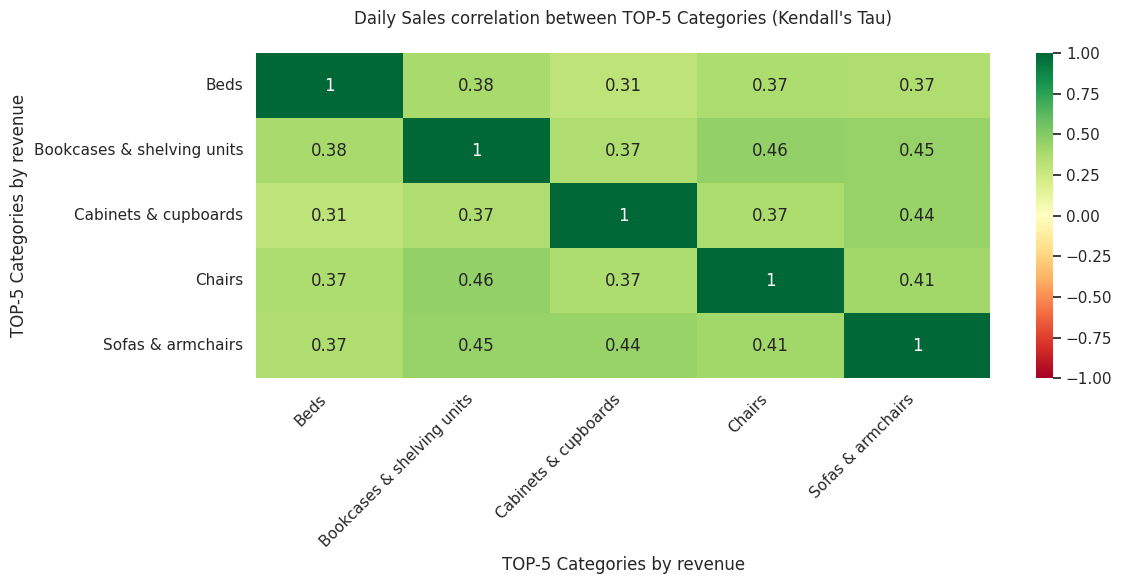

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    kendall_matrix_category,
    annot=True,
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
)

plt.title("Daily Sales correlation between TOP-5 Categories (Kendall's Tau)\n")
plt.xlabel("TOP-5 Categories by revenue")
plt.ylabel("TOP-5 Categories by revenue")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

All results are statistically significant, as the p-value is below 0.05.

There are low to moderate positive correlations between the top 5 categories, suggesting that sales in one category may have a positive influence on another (e.g., through bundle options at checkout). However, these relationships are limited.

# Statistical Analysis between different user groups

## Comparison of registered and not registered users

In [ ]:
df['is_registered'] = df['id'].notnull()
daily_user_sales = df.groupby(['date', 'is_registered'])['price'].sum().unstack(fill_value=0)
daily_user_sales.columns = ['Not Registered', 'Registered']
daily_user_sales.head()

,Not Registered,Registered
date,,
2020-11-01,222745.5,21547.0
2020-11-02,310550.0,44956.8
2020-11-03,469829.1,29150.5
2020-11-04,318204.9,20982.2
2020-11-05,365942.0,25334.6


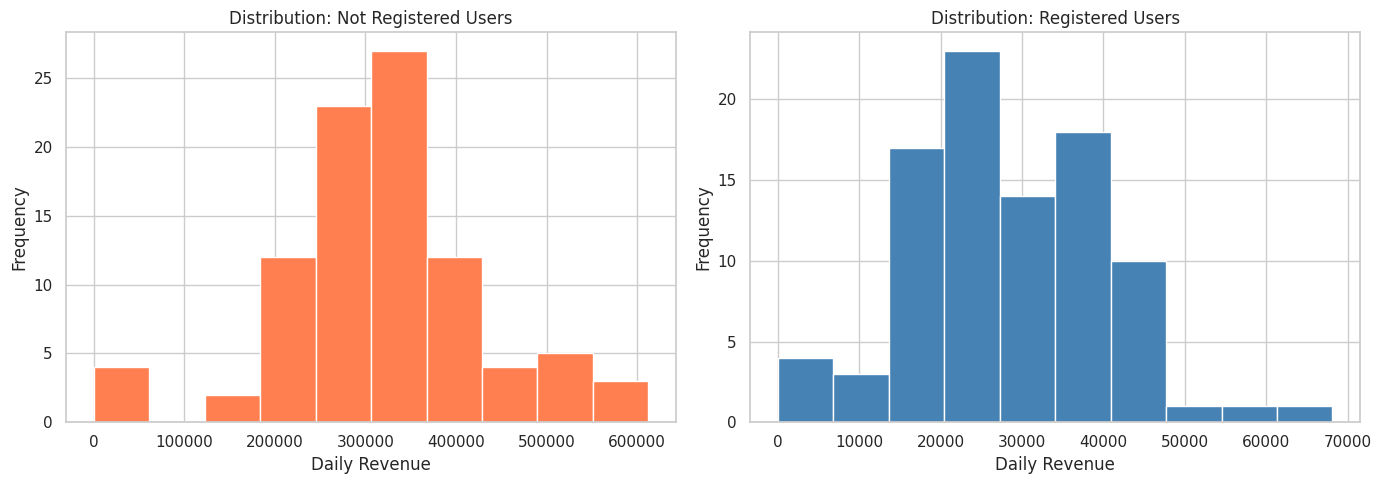

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(daily_user_sales['Not Registered'], color='coral')
ax[0].set_title('Distribution: Not Registered Users')
ax[0].set_xlabel('Daily Revenue')
ax[0].set_ylabel('Frequency')

ax[1].hist(daily_user_sales['Registered'], color='steelblue')
ax[1].set_title('Distribution: Registered Users')
ax[1].set_xlabel('Daily Revenue')
ax[1].set_ylabel('Frequency')

plt.tight_layout()

plt.show()

In [ ]:
for group in daily_user_sales.columns:
    stat, p_value = normaltest(daily_user_sales[group])

    print(f"Normality Test for: {group}")
    print(f"p-value: {p_value}")

    if p_value < 0.05:
        print("Result: Statistically Significant (p < 0.05)\n")
    else:
        print("Result: Not Statistically Significant (p >= 0.05)\n")

Normality Test for: Not Registered
p-value: 0.026362411185738954
Result: Statistically Significant (p < 0.05)

Normality Test for: Registered
p-value: 0.25716198091602527
Result: Not Statistically Significant (p >= 0.05)



Based on the calculations and graphs, we can state that Registered users are normally distributed while Not registered are not normally distributed.

Since at least one group is not normally distributed, we should use non-parametric tests to check if there are differences between groups. For that, we'll use Mann-Whitney test that is created to compare 2 non-parametric sets.

In [ ]:
for group in daily_user_sales.columns:
    stat, p_value = normaltest(daily_user_sales[group])
    print(f"{group} p-value: {p_value}")

stat, p_value_test = mannwhitneyu(daily_user_sales['Not Registered'],
                              daily_user_sales['Registered'])

print(f"\np-value: {p_value_test}\n")

if p_value_test < 0.05:
    print("Result: Significant difference found between groups.")
else:
    print("Result: No significant difference found.")

Not Registered p-value: 0.026362411185738954
Registered p-value: 0.25716198091602527

p-value: 8.379540669190225e-27

Result: Significant difference found between groups.


Based on the results, there is a statistically significant differences between 2 groups. It suggests that registration status is a primary driver of revenue, justifying further investment in the user registration funnel.

## Comparison of Traffic Channels

We already explored Traffic channels in the chapter above. Now we're running Kruskal-Wallis test to compare more than 2 non-parametric datasets.

In [ ]:
channel_samples = [daily_channels[col] for col in daily_channels.columns]

# Run the Kruskal-Wallis test
stat, p_value = kruskal(*channel_samples)

print(f"Kruskal-Wallis H-test results:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")

if p_value < 0.05:
    print("\nResult: Statistically Significant")
else:
    print("\nResult: Not Statistically Significant.")

Kruskal-Wallis H-test results:
Statistic: 296.2573085894095
p-value: 6.951906572594659e-63

Result: Statistically Significant


The marketing channels do not perform the same. There is a statistically significant difference in the amount of sales generated across the various channels.

## Comparison of Proportions: Organic Channel in Europe and Americas

In [ ]:
continents_df = df[df['continent'].isin(['Europe', 'Americas'])]
total_sessions = continents_df.groupby('continent')['ga_session_id'].count()
organic_sessions = continents_df[continents_df['channel'] == 'Organic Search'].groupby('continent')['ga_session_id'].count()

In [ ]:
import statsmodels.api as sm

organics = [organic_sessions['Americas'], organic_sessions['Europe']]
totals = [total_sessions['Americas'], total_sessions['Europe']]

# 2. Perform the test
z_stat, p_value = sm.stats.proportions_ztest(organics, totals)

print(f"Z-statistic: {z_stat}")
print(f"P-value: {p_value}")

# 3. Simple Interpretation
if p_value < 0.05:
    print("\nResult: Significant difference found in the share of organic traffic.")
else:
    print("\nResult: No statistically significant difference between regions.")

Z-statistic: -0.28951412926103953
P-value: 0.7721879690501752

Result: No statistically significant difference between regions.


Based on our results, in both regions, Organic Search performs almost on the same level and there is no statistically significant difference between them.

# Tableau Public Dashboard

In [ ]:
drive.mount('/content/drive')

folder_path = '/content/drive/My Drive/Mate/Portfolio/project_1/final_csv/'
file_name = 'portfolio_project_1.csv'

df.to_csv(folder_path + file_name, index=False)

print(f"Successfully saved to: {folder_path + file_name}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully saved to: /content/drive/My Drive/Mate/Portfolio/project_1/final_csv/portfolio_project_1.csv


Link to the Tableau Public Dashboard:
[Tableau Public Dashboard - Portfolio Project 1](https://public.tableau.com/views/PortfolioProject1_17785132950930/E-commercePerformanceAnalysis?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

# Conclusions

We analyzed **349,545 records** covering user sessions across **6 continents** and **108 countries**. During the period from **November 1st, 2020 to January 31st, 2021**, these sessions resulted in **33,538 orders** and **27,945 registered customers**.

## Data Collection
* Some `language` data is missing, which may indicate issues in the data collection process.
* Many NULL values were kept because they represent users without purchases or sessions not linked to accounts.

**Recommendations**
* Improve the language data collection process.
* Keep NULL values that have business meaning instead of replacing them artificially.

## Business Activity Overview
* The **United States** generated the highest revenue and significantly outperformed all other countries.
* Most product categories contain a small number of very expensive products.
* USA top-selling categories are very similar to the global top categories, and visualizations suggest that the USA generates around **50% of total consumption**.

**Recommendations**
* Analyze the USA separately, as it strongly affects overall results and may hide trends in smaller countries.
* Consider creating a separate premium segment for high-priced products.

## Devices & Traffic Channels
* **Tablets** generate less than **3%** of total revenue.
* Most traffic comes from **Organic Search**.

**Recommendations**
* Consider reducing or stopping tablet support to optimize operational costs.
* Continue investing in SEO and website improvements, since Organic Search performs very well and doesn't require direct advertising costs.

## Users & Accounts
* Around **21.5%** of users are unsubscribed from newsletters.
* Almost **30%** of users have not verified their email.
* Most users are from the USA, while India, Canada, and the UK are also among the leading countries.

**Recommendations**
* Improve newsletter retention campaigns.
* Send reminder emails to users who have not verified their accounts (yet).
* Continue focusing marketing efforts on English-speaking countries.

## Sales Dynamics
* Sales are noticeably stronger during weekdays, especially **Tuesday and Wednesday**.
* Weekend sales are lower.
* No orders were recorded at the end of January despite active sessions.

**Recommendations**
* Launch major marketing campaigns during weekdays.
* Use discounts or special offers during weekends to stimulate demand.
* Investigate the absence of orders at the end of January to determine whether it was caused by missing data or an actual drop in sales.

## Correlations
* Organic Search shows a **moderate-to-strong correlation (0.6)** with revenue.
* Registration has a statistically significant relationship with purchases.

**Recommendations**
* Continue strengthening Organic Search channels, as users who arrive organically are more likely to make purchases.
* Encourage more users to register by improving onboarding, loyalty programs, or registration benefits.

Overall, the analysis shows that the company already performs strongly in several areas, especially in Organic Search and the US market. At the same time, there are clear opportunities to improve data quality, increase user engagement, optimize operational costs, and strengthen sales stability.

Implementing these recommendations could help the company improve marketing efficiency, increase profitability, and support long-term growth.
